In [1]:
import os
import glob

from collections import Counter

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [2]:
spark = SparkSession.builder \
    .appName("NEON_SurfaceWater_CARI_HOPB_EDA") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 4.1.3


In [3]:
base_path = r"C:\Users\Jaya Vardhan\Desktop\BDA\NEON_chem-surfacewater"

print("Dataset folder exists:", os.path.exists(base_path))

Dataset folder exists: True


In [4]:
all_files = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".csv") and ("CARI" in file or "HOPB" in file):
            all_files.append(os.path.join(root, file))

print("Total CARI + HOPB CSV files:", len(all_files))

Total CARI + HOPB CSV files: 1691


In [5]:
file_types = Counter()

for f in all_files:
    filename = os.path.basename(f)

    if "swc_fieldData" in filename:
        file_types["fieldData"] += 1

    elif "swc_domainLabData" in filename:
        file_types["domainLabData"] += 1

    elif "swc_externalLabDataByAnalyte" in filename:
        file_types["externalLabDataByAnalyte"] += 1

    elif "swc_externalLabBlanksByAnalyte" in filename:
        file_types["externalLabBlanksByAnalyte"] += 1

    elif "swc_asiPOMFieldData" in filename:
        file_types["asiPOMFieldData"] += 1

    elif "categoricalCodes" in filename:
        file_types["categoricalCodes"] += 1

    elif "validation" in filename:
        file_types["validation"] += 1

    else:
        file_types["other"] += 1

for key, value in file_types.items():
    print(f"{key}: {value}")

categoricalCodes: 189
validation: 188
asiPOMFieldData: 182
domainLabData: 180
externalLabBlanksByAnalyte: 189
fieldData: 182
other: 403
externalLabDataByAnalyte: 178


In [6]:
field_files = [
    f for f in all_files
    if "swc_fieldData" in os.path.basename(f)
]

print("Field files:", len(field_files))
print(field_files[0])
field_sample = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv(field_files[0])

print("Rows:", field_sample.count())
print("Columns:", len(field_sample.columns))

field_sample.printSchema()

Field files: 182
C:\Users\Jaya Vardhan\Desktop\BDA\NEON_chem-surfacewater\NEON.D01.HOPB.DP1.20093.001.2016-09.expanded.20260123T000749Z.RELEASE-2026\NEON.D01.HOPB.DP1.20093.001.swc_fieldData.2016-09.expanded.20260106T150128Z.csv
Rows: 1
Columns: 29
root
 |-- uid: string (nullable = true)
 |-- domainID: string (nullable = true)
 |-- siteID: string (nullable = true)
 |-- namedLocation: string (nullable = true)
 |-- collectDate: string (nullable = true)
 |-- parentSampleID: string (nullable = true)
 |-- sampleID: string (nullable = true)
 |-- replicateNumber: string (nullable = true)
 |-- processedDate: string (nullable = true)
 |-- processedDateFilters: string (nullable = true)
 |-- sampleVolumeFiltered: double (nullable = true)
 |-- shipmentTimeRange: string (nullable = true)
 |-- filtSampleCond: string (nullable = true)
 |-- filtSampleID: string (nullable = true)
 |-- filtSampleCode: string (nullable = true)
 |-- filtNutSampleCond: string (nullable = true)
 |-- filtNutSampleID: string 

In [7]:
print(field_sample.columns)

['uid', 'domainID', 'siteID', 'namedLocation', 'collectDate', 'parentSampleID', 'sampleID', 'replicateNumber', 'processedDate', 'processedDateFilters', 'sampleVolumeFiltered', 'shipmentTimeRange', 'filtSampleCond', 'filtSampleID', 'filtSampleCode', 'filtNutSampleCond', 'filtNutSampleID', 'filtNutSampleBarcode', 'rawSampleCond', 'rawSampleID', 'rawSampleCode', 'rawNutSampleCond', 'rawNutSampleID', 'rawNutSampleBarcode', 'pcnSampleCond', 'pcnSampleID', 'pcnSampleCode', 'fieldDataQF', 'remarks']


In [8]:
external_files = [
    f for f in all_files
    if "swc_externalLabDataByAnalyte" in os.path.basename(f)
]

print("External lab files:", len(external_files))
print(external_files[0])
external_sample = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv(external_files[0])

print("Rows:", external_sample.count())
print("Columns:", len(external_sample.columns))

external_sample.printSchema()
print(external_sample.columns)

External lab files: 178
C:\Users\Jaya Vardhan\Desktop\BDA\NEON_chem-surfacewater\NEON.D01.HOPB.DP1.20093.001.2016-10.expanded.20260123T000749Z.RELEASE-2026\NEON.D01.HOPB.DP1.20093.001.swc_externalLabDataByAnalyte.2016-10.expanded.20260106T145749Z.csv
Rows: 31
Columns: 19
root
 |-- uid: string (nullable = true)
 |-- domainID: string (nullable = true)
 |-- siteID: string (nullable = true)
 |-- namedLocation: string (nullable = true)
 |-- sampleID: string (nullable = true)
 |-- sampleCode: string (nullable = true)
 |-- startDate: string (nullable = true)
 |-- collectDate: string (nullable = true)
 |-- laboratoryName: string (nullable = true)
 |-- analyte: string (nullable = true)
 |-- analyteConcentration: double (nullable = true)
 |-- analyteUnits: string (nullable = true)
 |-- analysisDate: string (nullable = true)
 |-- belowDetectionQF: string (nullable = true)
 |-- coolerTemp: double (nullable = true)
 |-- remarks: string (nullable = true)
 |-- shipmentWarmQF: integer (nullable = true

In [9]:
external_all = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv(external_files)

print("Rows:", external_all.count())
print("Columns:", len(external_all.columns))

Rows: 13591
Columns: 19


In [10]:
external_all.select("analyte") \
    .distinct() \
    .orderBy("analyte") \
    .show(200, truncate=False)

+----------------------+
|analyte               |
+----------------------+
|ANC                   |
|Br                    |
|Ca                    |
|Cl                    |
|DIC                   |
|DOC                   |
|F                     |
|Fe                    |
|K                     |
|Mg                    |
|Mn                    |
|NH4 - N               |
|NO2 - N               |
|NO3+NO2 - N           |
|Na                    |
|Ortho - P             |
|SO4                   |
|Si                    |
|TDN                   |
|TDP                   |
|TDS                   |
|TN                    |
|TOC                   |
|TP                    |
|TPC                   |
|TPN                   |
|TSS                   |
|TSS - Dry Mass        |
|UV Absorbance (254 nm)|
|UV Absorbance (280 nm)|
|specificConductance   |
+----------------------+



In [11]:
external_all.groupBy(
    "siteID",
    "analyte",
    "analyteUnits"
).count() \
.orderBy("siteID", desc("count")) \
.show(300, truncate=False)

+------+----------------------+-------------------------+-----+
|siteID|analyte               |analyteUnits             |count|
+------+----------------------+-------------------------+-----+
|CARI  |TPC                   |microgramsPerLiter       |268  |
|CARI  |TPN                   |microgramsPerLiter       |262  |
|CARI  |TP                    |milligramsPerLiter       |238  |
|CARI  |NH4 - N               |milligramsPerLiter       |237  |
|CARI  |Ortho - P             |milligramsPerLiter       |237  |
|CARI  |NO2 - N               |milligramsPerLiter       |237  |
|CARI  |TDP                   |milligramsPerLiter       |237  |
|CARI  |NO3+NO2 - N           |milligramsPerLiter       |232  |
|CARI  |TN                    |milligramsPerLiter       |220  |
|CARI  |TOC                   |milligramsPerLiter       |218  |
|CARI  |Mn                    |milligramsPerLiter       |216  |
|CARI  |Fe                    |milligramsPerLiter       |216  |
|CARI  |Mg                    |milligram

In [12]:
from pyspark.sql.functions import col, count, countDistinct, desc, min, max, avg
common_analytes = external_all.groupBy("analyte") \
    .agg(countDistinct("siteID").alias("number_of_sites")) \
    .filter(col("number_of_sites") == 2) \
    .orderBy("analyte")

common_analytes.show(200, truncate=False)

+----------------------+---------------+
|analyte               |number_of_sites|
+----------------------+---------------+
|ANC                   |2              |
|Br                    |2              |
|Ca                    |2              |
|Cl                    |2              |
|DIC                   |2              |
|DOC                   |2              |
|F                     |2              |
|Fe                    |2              |
|K                     |2              |
|Mg                    |2              |
|Mn                    |2              |
|NH4 - N               |2              |
|NO2 - N               |2              |
|NO3+NO2 - N           |2              |
|Na                    |2              |
|Ortho - P             |2              |
|SO4                   |2              |
|Si                    |2              |
|TDN                   |2              |
|TDP                   |2              |
|TDS                   |2              |
|TN             

In [13]:
external_all.groupBy("analyte", "analyteUnits") \
    .agg(
        count("*").alias("records")
    ) \
    .orderBy("analyte", desc("records")) \
    .show(200, truncate=False)

+----------------------+-------------------------+-------+
|analyte               |analyteUnits             |records|
+----------------------+-------------------------+-------+
|ANC                   |milliequivalentsPerLiter |191    |
|Br                    |milligramsPerLiter       |406    |
|Br                    |NULL                     |45     |
|Ca                    |milligramsPerLiter       |451    |
|Cl                    |milligramsPerLiter       |406    |
|Cl                    |NULL                     |45     |
|DIC                   |milligramsPerLiter       |444    |
|DIC                   |NULL                     |6      |
|DOC                   |milligramsPerLiter       |444    |
|DOC                   |NULL                     |6      |
|F                     |milligramsPerLiter       |406    |
|F                     |NULL                     |45     |
|Fe                    |milligramsPerLiter       |451    |
|K                     |milligramsPerLiter       |451   

In [14]:
external_all.groupBy("analyte").agg(
    count("*").alias("total_records"),
    count("analyteConcentration").alias("valid_values"),
    (count("*") - count("analyteConcentration")).alias("missing_values")
).orderBy(desc("total_records")).show(100, truncate=False)

+----------------------+-------------+------------+--------------+
|analyte               |total_records|valid_values|missing_values|
+----------------------+-------------+------------+--------------+
|TPC                   |545          |543         |2             |
|TPN                   |525          |521         |4             |
|TP                    |480          |477         |3             |
|TDP                   |479          |468         |11            |
|Ortho - P             |479          |438         |41            |
|NO2 - N               |479          |411         |68            |
|NH4 - N               |479          |452         |27            |
|NO3+NO2 - N           |474          |450         |24            |
|TN                    |461          |455         |6             |
|TOC                   |457          |453         |4             |
|TDN                   |455          |445         |10            |
|K                     |451          |445         |6          

In [15]:
quality_summary = external_all.groupBy("analyte").agg(
    count("*").alias("total"),
    count("analyteConcentration").alias("valid"),
    (count("*") - count("analyteConcentration")).alias("missing")
).withColumn(
    "missing_percent",
    round(col("missing") / col("total") * 100, 2)
).orderBy("missing_percent")

quality_summary.show(40, truncate=False)

+----------------------+-----+-----+-------+---------------+
|analyte               |total|valid|missing|missing_percent|
+----------------------+-----+-----+-------+---------------+
|specificConductance   |191  |191  |0      |0.0            |
|ANC                   |191  |191  |0      |0.0            |
|TPC                   |545  |543  |2      |0.37           |
|TP                    |480  |477  |3      |0.63           |
|TPN                   |525  |521  |4      |0.76           |
|TOC                   |457  |453  |4      |0.88           |
|TN                    |461  |455  |6      |1.3            |
|K                     |451  |445  |6      |1.33           |
|UV Absorbance (254 nm)|451  |445  |6      |1.33           |
|UV Absorbance (280 nm)|451  |445  |6      |1.33           |
|Mg                    |451  |445  |6      |1.33           |
|Si                    |451  |445  |6      |1.33           |
|SO4                   |451  |444  |7      |1.55           |
|DIC                   |

In [16]:
quality_summary.createOrReplaceTempView("quality_summary")

In [17]:
quality_summary.filter(
    col("valid") >= 200
).orderBy(
    desc("valid")
).show(40, truncate=False)

+----------------------+-----+-----+-------+---------------+
|analyte               |total|valid|missing|missing_percent|
+----------------------+-----+-----+-------+---------------+
|TPC                   |545  |543  |2      |0.37           |
|TPN                   |525  |521  |4      |0.76           |
|TP                    |480  |477  |3      |0.63           |
|TDP                   |479  |468  |11     |2.3            |
|TN                    |461  |455  |6      |1.3            |
|TOC                   |457  |453  |4      |0.88           |
|NH4 - N               |479  |452  |27     |5.64           |
|NO3+NO2 - N           |474  |450  |24     |5.06           |
|K                     |451  |445  |6      |1.33           |
|UV Absorbance (254 nm)|451  |445  |6      |1.33           |
|UV Absorbance (280 nm)|451  |445  |6      |1.33           |
|Mg                    |451  |445  |6      |1.33           |
|TDN                   |455  |445  |10     |2.2            |
|Si                    |

In [18]:
site_quality = external_all.groupBy("siteID", "analyte").agg(
    count("*").alias("total"),
    count("analyteConcentration").alias("valid")
).withColumn(
    "missing",
    col("total") - col("valid")
).withColumn(
    "valid_percent",
    round(col("valid") / col("total") * 100, 2)
).orderBy("analyte", "siteID")

site_quality.show(100, truncate=False)

+------+----------------------+-----+-----+-------+-------------+
|siteID|analyte               |total|valid|missing|valid_percent|
+------+----------------------+-----+-----+-------+-------------+
|CARI  |ANC                   |90   |90   |0      |100.0        |
|HOPB  |ANC                   |101  |101  |0      |100.0        |
|CARI  |Br                    |216  |129  |87     |59.72        |
|HOPB  |Br                    |235  |195  |40     |82.98        |
|CARI  |Ca                    |216  |201  |15     |93.06        |
|HOPB  |Ca                    |235  |220  |15     |93.62        |
|CARI  |Cl                    |216  |208  |8      |96.3         |
|HOPB  |Cl                    |235  |231  |4      |98.3         |
|CARI  |DIC                   |215  |211  |4      |98.14        |
|HOPB  |DIC                   |235  |231  |4      |98.3         |
|CARI  |DOC                   |215  |211  |4      |98.14        |
|HOPB  |DOC                   |235  |231  |4      |98.3         |
|CARI  |F 

In [19]:
good_features = site_quality.groupBy("analyte").agg(
    min("valid").alias("min_valid_across_sites")
).filter(
    col("min_valid_across_sites") >= 100
).orderBy(desc("min_valid_across_sites"))

good_features.show(100, truncate=False)

+----------------------+----------------------+
|analyte               |min_valid_across_sites|
+----------------------+----------------------+
|TPC                   |266                   |
|TPN                   |260                   |
|TP                    |237                   |
|TDP                   |232                   |
|NO3+NO2 - N           |222                   |
|NH4 - N               |222                   |
|TN                    |220                   |
|TOC                   |218                   |
|K                     |214                   |
|UV Absorbance (254 nm)|214                   |
|UV Absorbance (280 nm)|214                   |
|Mg                    |214                   |
|TDN                   |214                   |
|Si                    |214                   |
|SO4                   |213                   |
|Ortho - P             |211                   |
|DIC                   |211                   |
|DOC                   |211             

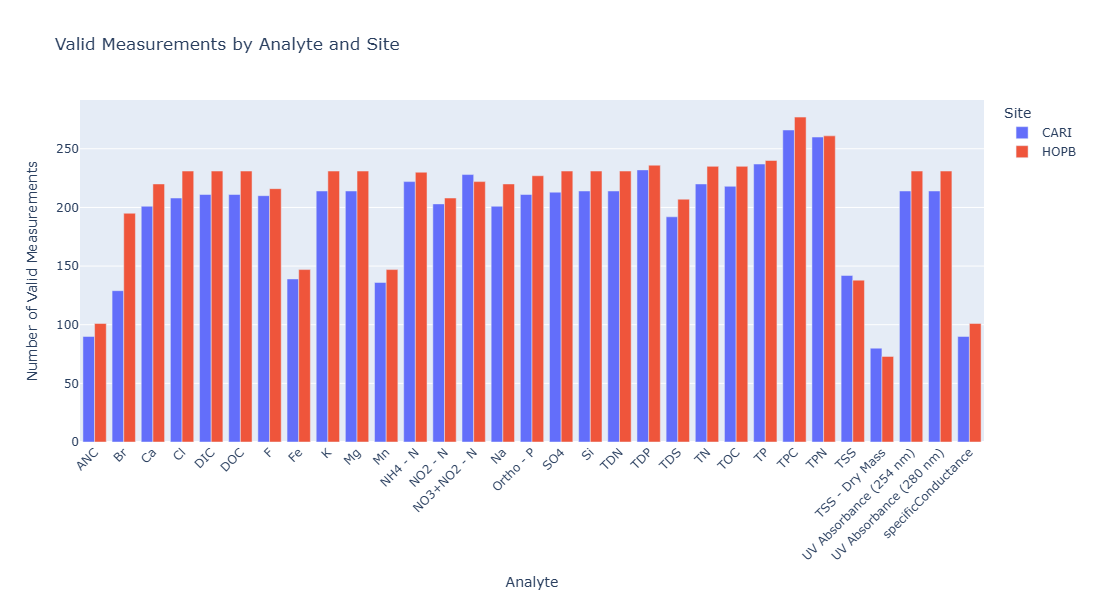

In [20]:
coverage_pd = site_quality.toPandas()

import plotly.express as px

fig = px.bar(
    coverage_pd,
    x="analyte",
    y="valid",
    color="siteID",
    barmode="group",
    title="Valid Measurements by Analyte and Site",
    labels={
        "analyte": "Analyte",
        "valid": "Number of Valid Measurements",
        "siteID": "Site"
    }
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600
)

fig.show()

In [ ]:
Interpretation:
The number of valid measurements varies across analytes and between CARI and HOPB.
Most analytes have more than 200 valid observations at each site, indicating good data availability for comparative analysis. 
TPC, TPN, TP, TDP, TN, TOC, and several major ions have particularly high coverage.
In contrast, ANC, specific conductance, and TSS-Dry Mass have comparatively fewer observations. 
Therefore, the analysis can confidently focus on the well-represented analytes, while variables with lower coverage should be interpreted with greater caution.

In [44]:
major_ions = [
    "Ca",
    "Mg",
    "Na",
    "K",
    "Cl",
    "SO4",
    "Br",
    "F"
]

major_ions_pd = external_all.filter(
    (col("analyte").isin(major_ions)) &
    (col("analyteUnits") == "milligramsPerLiter") &
    col("analyteConcentration").isNotNull()
).select(
    "siteID",
    "analyte",
    "analyteConcentration"
).toPandas()

print(major_ions_pd.shape)
major_ions_pd.head()

(3216, 3)


,siteID,analyte,analyteConcentration
0,CARI,Br,0.005
1,CARI,Mg,2.455
2,CARI,Na,0.612
3,CARI,Cl,2.090
4,CARI,Mg,2.416


Concentration files: 367


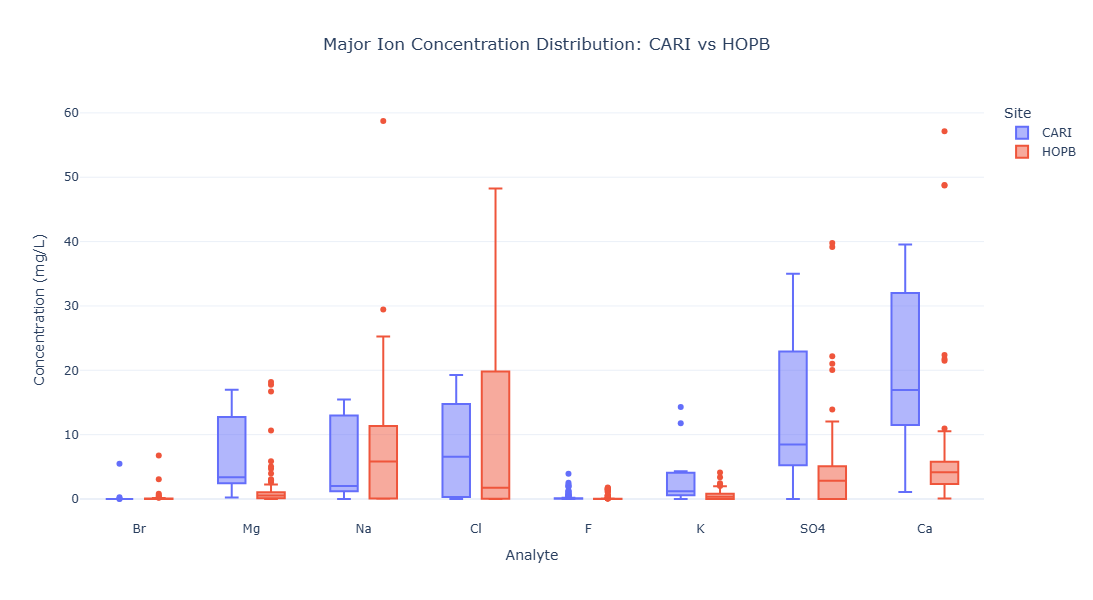

In [45]:
# Plot 2 – Major ion concentration distribution by site

# Load concentration files for CARI and HOPB
concentration_files_2sites = []

for f in all_files:
    if (
        ("CARI" in f.upper() or "HOPB" in f.upper())
        and f.lower().endswith(".csv")
    ):
        try:
            cols = pd.read_csv(f, nrows=0).columns.tolist()

            if "analyteConcentration" in cols and "analyte" in cols:
                concentration_files_2sites.append(f)

        except:
            pass

print("Concentration files:", len(concentration_files_2sites))

# Read both sites
two_site_chem = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(concentration_files_2sites)
)

# Keep only major ions
two_site_chem = two_site_chem.filter(
    col("analyte").isin(major_ions)
)

# Convert to Pandas
plot2_df = two_site_chem.select(
    "siteID",
    "analyte",
    "analyteConcentration"
).toPandas()

# Convert concentration to numeric
plot2_df["analyteConcentration"] = pd.to_numeric(
    plot2_df["analyteConcentration"],
    errors="coerce"
)

# Remove missing values
plot2_df = plot2_df.dropna(
    subset=["siteID", "analyte", "analyteConcentration"]
)

# Box plot
fig = px.box(
    plot2_df,
    x="analyte",
    y="analyteConcentration",
    color="siteID",
    title="Major Ion Concentration Distribution: CARI vs HOPB",
    labels={
        "analyte": "Analyte",
        "analyteConcentration": "Concentration (mg/L)",
        "siteID": "Site"
    }
)

fig.update_layout(
    height=600,
    title_x=0.5,
    template="plotly_white"
)

fig.show()

In [ ]:
CARI generally shows higher concentrations of Mg, Na, K, SO₄, and Ca compared with HOPB.
HOPB has higher chloride (Cl) concentrations and a wider variation in Cl values.
Ca and SO₄ show substantial variability at CARI, with several high values.
Br and F have very low concentrations at both sites.
Overall, the plot indicates clear differences in major-ion concentration and variability between CARI and HOPB, with CARI generally showing higher levels.

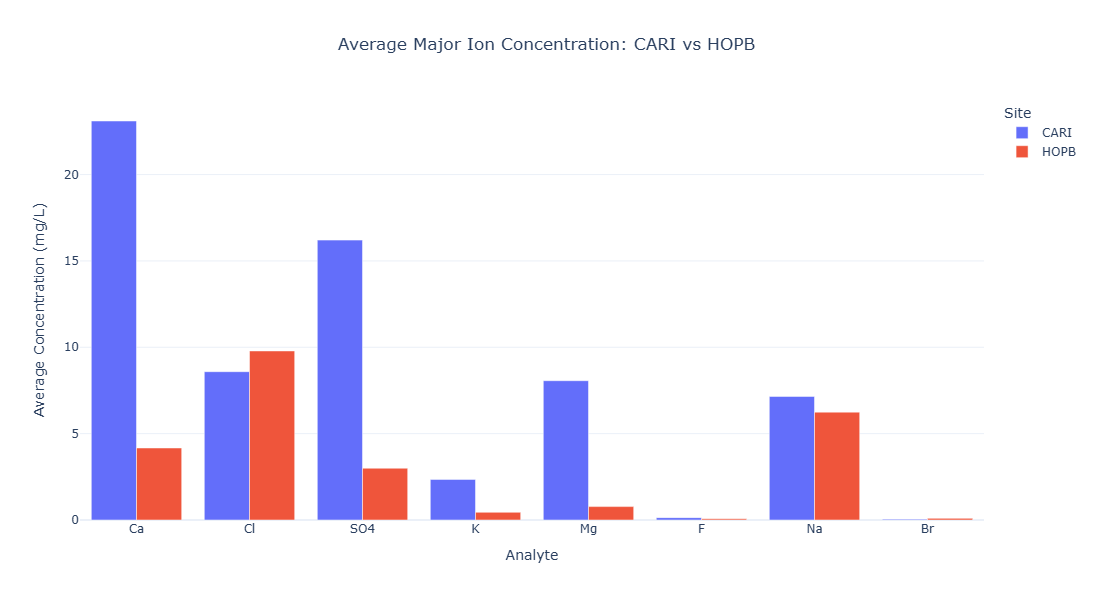

In [47]:
# Plot 3 – Average concentration of major ions by site

plot3_df = (
    two_site_chem
    .groupBy("siteID", "analyte")
    .agg(
        avg("analyteConcentration").alias("averageConcentration")
    )
    .toPandas()
)

plot3_df["averageConcentration"] = pd.to_numeric(
    plot3_df["averageConcentration"],
    errors="coerce"
)

plot3_df = plot3_df.dropna(
    subset=["averageConcentration"]
)

fig = px.bar(
    plot3_df,
    x="analyte",
    y="averageConcentration",
    color="siteID",
    barmode="group",
    title="Average Major Ion Concentration: CARI vs HOPB",
    labels={
        "analyte": "Analyte",
        "averageConcentration": "Average Concentration (mg/L)",
        "siteID": "Site"
    }
)

fig.update_layout(
    height=600,
    title_x=0.5,
    template="plotly_white"
)

fig.show()

In [ ]:
CARI has a much higher average concentration of Ca, SO₄, Mg, and K than HOPB.
HOPB has a higher average Cl concentration than CARI.
Na is relatively high at both sites, with CARI slightly higher.
F and Br have very low average concentrations at both sites.
Overall, CARI shows higher average concentrations for most major ions, while HOPB is particularly higher in chloride.

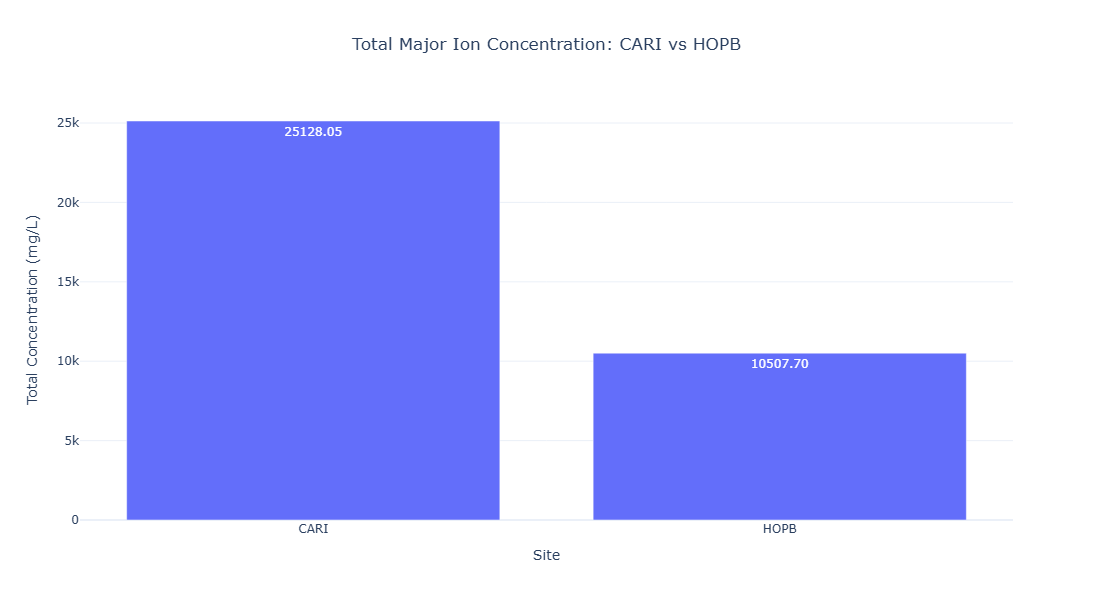

In [48]:
# Plot 4 – Total major-ion concentration by site

plot4_df = (
    two_site_chem
    .groupBy("siteID")
    .agg(
        sum("analyteConcentration").alias("totalConcentration")
    )
    .toPandas()
)

plot4_df["totalConcentration"] = pd.to_numeric(
    plot4_df["totalConcentration"],
    errors="coerce"
)

fig = px.bar(
    plot4_df,
    x="siteID",
    y="totalConcentration",
    title="Total Major Ion Concentration: CARI vs HOPB",
    labels={
        "siteID": "Site",
        "totalConcentration": "Total Concentration (mg/L)"
    },
    text_auto=".2f"
)

fig.update_layout(
    height=600,
    title_x=0.5,
    template="plotly_white"
)

fig.show()

In [ ]:
CARI has a total major-ion concentration of approximately 25,128 mg/L.
HOPB has a total concentration of approximately 10,508 mg/L.
CARI total concentration is therefore more than twice that of HOPB.
This indicates that CARI has a substantially higher overall major-ion concentration than HOPB.

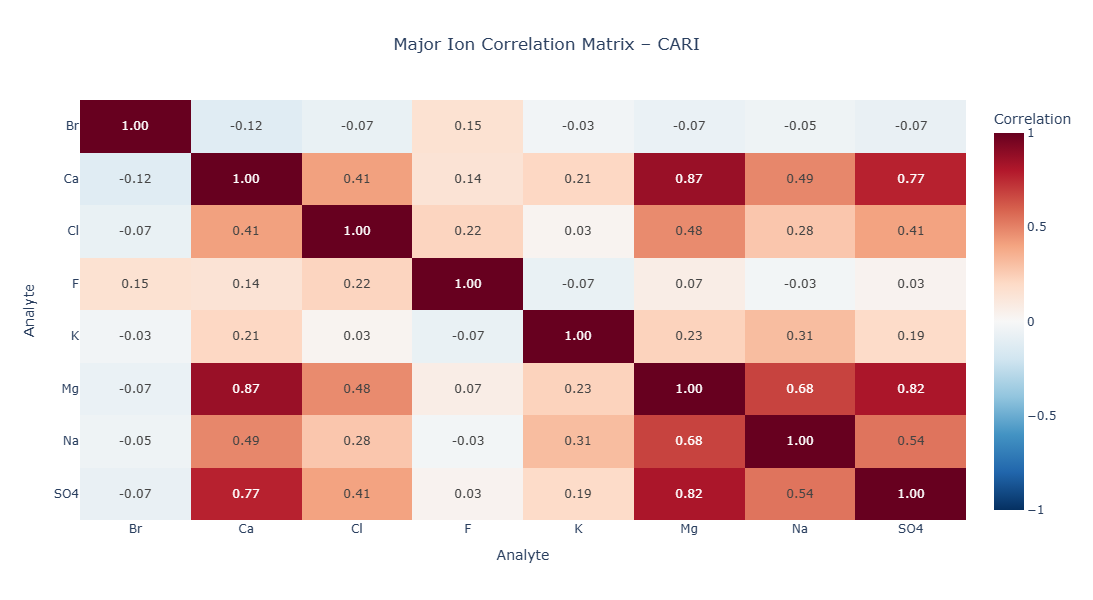

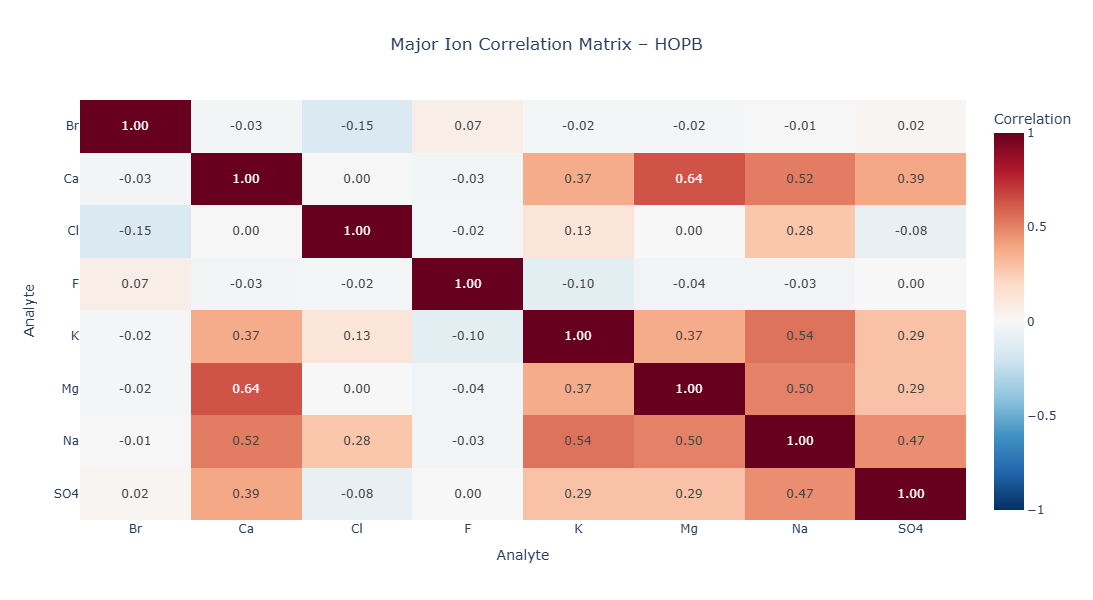

In [51]:
import numpy as np
import pandas as pd
import plotly.express as px

# 1. Select relevant columns (including your sample/date identifier)
plot5_df = two_site_chem.select(
    "siteID", "analyte", "analyteConcentration", "sampleID"
).toPandas()

# 2. Convert concentration to numeric
plot5_df["analyteConcentration"] = pd.to_numeric(
    plot5_df["analyteConcentration"], errors="coerce"
)

# 3. Remove missing values
plot5_df = plot5_df.dropna(subset=["analyte", "analyteConcentration"])

# 4. Create separate correlation matrix for each site
for site in ["CARI", "HOPB"]:

    site_df = plot5_df[plot5_df["siteID"] == site]

    # Pivot analytes into columns using sampleID as index
    pivot_df = site_df.pivot_table(
        index="sampleID",  # <-- Grouping by sample/date fixes the NaN blank spots
        columns="analyte",
        values="analyteConcentration",
        aggfunc="mean",  # Aggregates if duplicate measurements exist
    )

    # Calculate correlation matrix
    corr_matrix = pivot_df.corr()

    # Create heatmap
    fig = px.imshow(
        corr_matrix,
        text_auto=".2f",
        aspect="auto",
        title=f"Major Ion Correlation Matrix – {site}",
        labels={"x": "Analyte", "y": "Analyte", "color": "Correlation"},
        zmin=-1,
        zmax=1,
        color_continuous_scale="RdBu_r",  # Added color scale so negative/positive correlations stand out
    )

    fig.update_layout(height=600, title_x=0.5, template="plotly_white")

    fig.show()

In [ ]:
CARI Site: Hydrochemistry is heavily driven by mineral dissolution (e.g., gypsum and dolomite weathering), evidenced by strong correlations between calcium, magnesium, and sulfate .
HOPB Site: Shows significantly weaker mineral coupling, with moderate correlations restricted mainly to cations like calcium, magnesium, and sodium .
Anion Behavior: Sulfates and chlorides at HOPB act independently of cations, suggesting atmospheric precipitation or surface runoff rather than bedrock interaction.
Conservative Ions: Bromide and fluoride at both sites remain decoupled from major ions ($r \approx -0.15 \text{ to } 0.22$), indicating localized, independent sources.
Key Takeaway: CARI experiences distinct groundwater-bedrock weathering, while HOPB reflects a diluted, surface-dominated hydrology.